# Intro

https://docs.google.com/document/d/1XGVbEZDa58eGfv7g8V5xEPlrJkVaK-yTW469p9xQvIw/edit?tab=t.0


Pre-processing
1) Pedro - Dialogues are split by line_number, creating an unnecessary row on the dataset
2) Pedro - Multi-Word Names and Title/Honorific Handling
3) ✅ Renan - Quotation Attribution and Implicit Speaker Ambiguity


Visualization
1) Pedro - Speaker Distribution & Frequency - words per scene/act
2) ✅ Renan - Scene-Level Interaction Heatmap - which character pairs share the most scenes?

Deliverables
1) Thea - Create PDF
2) Thea - Create presentation
3) All - code (this notebook)

# Setup

In [ ]:
%pip install -q --upgrade pip kagglehub
%pip install pandas
%pip install -q seaborn matplotlib

import kagglehub
import os
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

path = kagglehub.dataset_download("umerhaddii/shakespeare-plays-dialogues")

print("Path to dataset files:", path)

# List all CSV files in the dataset
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print(f'Found {len(csv_files)} CSV files:')
for f in sorted(csv_files):
    size_kb = os.path.getsize(os.path.join(path, f)) / 1024
    print(f'  {f} ({size_kb:.1f} KB)')

# Read romeo_juliet.csv
rj_path = os.path.join(path, 'romeo_juliet.csv')
df = pd.read_csv(rj_path)
print(f'\nShape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(4000)

Using Colab cache for faster access to the 'shakespeare-plays-dialogues' dataset.
Path to dataset files: /kaggle/input/shakespeare-plays-dialogues
Found 3 CSV files:
  hamlet.csv (289.1 KB)
  macbeth.csv (167.4 KB)
  romeo_juliet.csv (224.6 KB)

Shape: (3282, 5)
Columns: ['act', 'scene', 'character', 'dialogue', 'line_number']


,act,scene,character,dialogue,line_number
0,Act I,Prologue,Chorus,"Two households, both alike in dignity,",1.0
1,Act I,Prologue,Chorus,"In fair Verona, where we lay our scene,",2.0
2,Act I,Prologue,Chorus,"From ancient grudge break to new mutiny,",3.0
3,Act I,Prologue,Chorus,Where civil blood makes civil hands unclean.,4.0
4,Act I,Prologue,Chorus,From forth the fatal loins of these two foes,5.0
...,...,...,...,...,...
3277,Act V,Scene III,Prince,"Go hence, to have more talk of these sad things;",3090.0
3278,Act V,Scene III,Prince,"Some shall be pardon'd, and some punished:",3091.0
3279,Act V,Scene III,Prince,For never was a story of more woe,3092.0
3280,Act V,Scene III,Prince,Than this of Juliet and her Romeo.,3093.0


# Pre-processing - creates a new "partipants" column - Quotation Attribution and Implicit Speaker Ambiguity

In [ ]:
# Pre-processing
# Quotation Attribution and Implicit Speaker Ambiguity
# Creates a new "partipants" column in DataFrame `df`

import re
import html
from typing import Optional
from collections import defaultdict


def add_participants(df: pd.DataFrame, direction_col='character', dialogue_col='dialogue',
                     act_col='act', scene_col='scene', stage_label='[stage direction]') -> pd.DataFrame:
    """
    Add a 'participants' column to a Shakespeare-style dialogue DataFrame.
    Tracks who is physically on-stage by parsing Enter / Exit / Exeunt / Re-enter
    stage directions.  Only characters that actually speak somewhere in the play
    are ever inserted (no invented 'Guests', 'Attendants', etc.).
    """
    # 1. Build a lookup of every real speaker in the corpus
    speakers = df.loc[df[direction_col] != stage_label, direction_col].unique()
    char_map = {}
    for c in speakers:
        key = c.strip().upper()
        char_map[key] = c
        if key.startswith('THE '):
            char_map[key[4:]] = c          # 'The Prince' → 'Prince'

    def _clean(text: str) -> str:
        text = text.strip()
        text = re.sub(r'\s+', ' ', text)
        for pat in [r'^[aA]\s+', r'^[tT][hH][eE]\s+', r'^[aA][nN][dD]\s+',
                    r'^[wW][iI][tT][hH]\s+', r'^[hH][iI][sS]\s+', r'^[hH][eE][rR]\s+']:
            text = re.sub(pat, '', text)
        text = re.sub(r',.*$', '', text)
        text = re.sub(r'\s+(of|with|in|armed|bearing|meeting|booted|disguised|asleep|who)\s+.*$', '',
                      text, flags=re.IGNORECASE)
        text = re.sub(r'\s+(above|below|within|without|booted|disguised|asleep)$', '',
                      text, flags=re.IGNORECASE)
        return text.strip()

    def _extract(text: str) -> list[str]:
        names = []
        for part in re.split(r',\s*|;\s*|\s+and\s+', text):
            cleaned = _clean(part)
            if cleaned and cleaned.upper() in char_map:
                names.append(char_map[cleaned.upper()])
        return names

    def _process_direction(dial: str, present: list, last_speaker: Optional[str]) -> list:
        d = html.unescape(str(dial).strip())
        du = d.upper()

        m = re.search(r'\b(ENTER|RE-ENTER)\b', du)
        if m:
            after = d[m.end():].strip()
            after = re.sub(r'^,\s*', '', after)
            for n in _extract(after):
                if n not in present:
                    present.append(n)
            return present

        if du.startswith('EXEUNT'):
            after = re.sub(r'^EXEUNT\s*', '', d, flags=re.IGNORECASE).strip()
            if not after or after in ('.', ','):
                present = []
            elif re.match(r'^all\s+but\s+', after, flags=re.IGNORECASE):
                after = re.sub(r'^all\s+but\s+', '', after, flags=re.IGNORECASE)
                keep = _extract(after)
                present = [n for n in keep if n in present]
            else:
                for n in _extract(after):
                    if n in present:
                        present.remove(n)
            return present

        if du.startswith('EXIT'):
            after = re.sub(r'^EXIT\s*', '', d, flags=re.IGNORECASE).strip()
            if not after or after in ('.', ','):
                if last_speaker and last_speaker in present:
                    present.remove(last_speaker)
            else:
                for n in _extract(after):
                    if n in present:
                        present.remove(n)
            return present

        return present

    # 2. Walk the DataFrame row-by-row
    participants = []
    present = []
    last_speaker = None
    cur_act, cur_scene = None, None

    for _, row in df.iterrows():
        act, scene = row[act_col], row[scene_col]
        char = row[direction_col]
        dial = row[dialogue_col]

        if (act, scene) != (cur_act, cur_scene):
            present = []
            last_speaker = None
            cur_act, cur_scene = act, scene

        if char == stage_label:
            present = _process_direction(dial, present, last_speaker)
        else:
            if char not in present:
                present.append(char)
            last_speaker = char

        participants.append(list(present))

    return df.assign(participants=participants)


# --- Run it ---
df = add_participants(df)

# --- Quick sanity checks ---
print('Rows:', len(df))
print('Columns:', list(df.columns))

df.head(4000)


Rows: 3282
Columns: ['act', 'scene', 'character', 'dialogue', 'line_number', 'participants']


,act,scene,character,dialogue,line_number,participants
0,Act I,Prologue,Chorus,"Two households, both alike in dignity,",1.0,[Chorus]
1,Act I,Prologue,Chorus,"In fair Verona, where we lay our scene,",2.0,[Chorus]
2,Act I,Prologue,Chorus,"From ancient grudge break to new mutiny,",3.0,[Chorus]
3,Act I,Prologue,Chorus,Where civil blood makes civil hands unclean.,4.0,[Chorus]
4,Act I,Prologue,Chorus,From forth the fatal loins of these two foes,5.0,[Chorus]
...,...,...,...,...,...,...
3277,Act V,Scene III,Prince,"Go hence, to have more talk of these sad things;",3090.0,"[Paris, Romeo, Balthasar, Juliet, First Watchm..."
3278,Act V,Scene III,Prince,"Some shall be pardon'd, and some punished:",3091.0,"[Paris, Romeo, Balthasar, Juliet, First Watchm..."
3279,Act V,Scene III,Prince,For never was a story of more woe,3092.0,"[Paris, Romeo, Balthasar, Juliet, First Watchm..."
3280,Act V,Scene III,Prince,Than this of Juliet and her Romeo.,3093.0,"[Paris, Romeo, Balthasar, Juliet, First Watchm..."


# Pre-processing - Multi-Word Names and Title/Honorific Handling

In [ ]:
# Multi-Word Names + Title/Honorific Handling for Shakespeare dataset

import re

TITLES = {
    "MR", "MRS", "MS", "DR", "SIR", "LORD", "LADY",
    "PRINCE", "KING", "QUEEN", "DUKE", "DUCHESS",
    "FRIAR", "CAPTAIN", "SERVANT", "NURSE"
}

def normalize_character(name: str):
    if not isinstance(name, str):
        return {
            "title": None,
            "first_name": None,
            "last_name": None,
            "normalized_name": None
        }

    # Clean text
    name = name.strip().upper()
    name = re.sub(r'\s+', ' ', name)

    parts = name.split()

    title = None
    first_name = None
    last_name = None

    # Case 1: starts with title
    if parts[0] in TITLES:
        title = parts[0]
        remaining = parts[1:]

        if len(remaining) == 0:
            # e.g., "PRINCE"
            first_name = title
        elif len(remaining) == 1:
            # e.g., "LADY CAPULET"
            last_name = remaining[0]
        else:
            # e.g., "KING HENRY IV"
            first_name = remaining[0]
            last_name = " ".join(remaining[1:])
    else:
        # No title
        if len(parts) == 1:
            first_name = parts[0]
        elif len(parts) == 2:
            first_name, last_name = parts
        else:
            first_name = parts[0]
            last_name = " ".join(parts[1:])

    normalized = " ".join([p for p in [first_name, last_name] if p])

    return {
        "title": title,
        "first_name": first_name,
        "last_name": last_name,
        "normalized_name": normalized
    }


# Apply to DataFrame
parsed = df['character'].apply(normalize_character)

df['title'] = parsed.apply(lambda x: x['title'])
df['first_name'] = parsed.apply(lambda x: x['first_name'])
df['last_name'] = parsed.apply(lambda x: x['last_name'])
df['normalized_name'] = parsed.apply(lambda x: x['normalized_name'])

# Preview results
df.head(4000)

,act,scene,character,dialogue,line_number,participants,title,first_name,last_name,normalized_name
0,Act I,Prologue,Chorus,"Two households, both alike in dignity,",1.0,[Chorus],None,CHORUS,None,CHORUS
1,Act I,Prologue,Chorus,"In fair Verona, where we lay our scene,",2.0,[Chorus],None,CHORUS,None,CHORUS
2,Act I,Prologue,Chorus,"From ancient grudge break to new mutiny,",3.0,[Chorus],None,CHORUS,None,CHORUS
3,Act I,Prologue,Chorus,Where civil blood makes civil hands unclean.,4.0,[Chorus],None,CHORUS,None,CHORUS
4,Act I,Prologue,Chorus,From forth the fatal loins of these two foes,5.0,[Chorus],None,CHORUS,None,CHORUS
...,...,...,...,...,...,...,...,...,...,...
3277,Act V,Scene III,Prince,"Go hence, to have more talk of these sad things;",3090.0,"[Paris, Romeo, Balthasar, Juliet, First Watchm...",PRINCE,PRINCE,None,PRINCE
3278,Act V,Scene III,Prince,"Some shall be pardon'd, and some punished:",3091.0,"[Paris, Romeo, Balthasar, Juliet, First Watchm...",PRINCE,PRINCE,None,PRINCE
3279,Act V,Scene III,Prince,For never was a story of more woe,3092.0,"[Paris, Romeo, Balthasar, Juliet, First Watchm...",PRINCE,PRINCE,None,PRINCE
3280,Act V,Scene III,Prince,Than this of Juliet and her Romeo.,3093.0,"[Paris, Romeo, Balthasar, Juliet, First Watchm...",PRINCE,PRINCE,None,PRINCE


# Pre-processing - Dialogues are split by line_number, creating an unnecessary row on the dataset

In [ ]:
# Pre-processing: Merge dialogues split by line_number

def merge_split_dialogues(df):
    merged_rows = []

    current_row = None

    for _, row in df.iterrows():
        row_dict = row.to_dict()

        if current_row is None:
            current_row = row_dict
            continue

        # Conditions to MERGE
        same_character = row_dict['character'] == current_row['character']
        same_scene = (
            row_dict['act'] == current_row['act'] and
            row_dict['scene'] == current_row['scene']
        )

        # line_number may be string → convert safely
        try:
            prev_line = int(current_row['line_number'])
            curr_line = int(row_dict['line_number'])
            consecutive = curr_line == prev_line + 1
        except:
            consecutive = False

        # Do NOT merge stage directions
        is_stage = row_dict['character'] == '[stage direction]'
        prev_is_stage = current_row['character'] == '[stage direction]'

        if same_character and same_scene and consecutive and not is_stage and not prev_is_stage:
            # Merge dialogue text
            current_row['dialogue'] += ' ' + str(row_dict['dialogue'])
            current_row['line_number'] = row_dict['line_number']  # update last line
        else:
            merged_rows.append(current_row)
            current_row = row_dict

    # append last row
    if current_row is not None:
        merged_rows.append(current_row)

    return pd.DataFrame(merged_rows)


# Apply it
df = merge_split_dialogues(df)

# Reset index after merge
df = df.reset_index(drop=True)

# Check result
print("New shape:", df.shape)
df.head(4000)

New shape: (1068, 10)


,act,scene,character,dialogue,line_number,participants,title,first_name,last_name,normalized_name
0,Act I,Prologue,Chorus,"Two households, both alike in dignity, In fair...",14.0,[Chorus],None,CHORUS,None,CHORUS
1,Act I,Scene I,[stage direction],"Enter SAMPSON and GREGORY, of the house of Cap...",NaN,"[Sampson, Gregory]",None,[STAGE,DIRECTION],[STAGE DIRECTION]
2,Act I,Scene I,Sampson,"Gregory, o' my word, we'll not carry coals.",15.0,"[Sampson, Gregory]",None,SAMPSON,None,SAMPSON
3,Act I,Scene I,Gregory,"No, for then we should be colliers.",16.0,"[Sampson, Gregory]",None,GREGORY,None,GREGORY
4,Act I,Scene I,Sampson,"I mean, an we be in choler, we'll draw.",17.0,"[Sampson, Gregory]",None,SAMPSON,None,SAMPSON
...,...,...,...,...,...,...,...,...,...,...
1063,Act V,Scene III,Capulet,"O brother Montague, give me thy hand: This is ...",3080.0,"[Paris, Romeo, Balthasar, Juliet, First Watchm...",None,CAPULET,None,CAPULET
1064,Act V,Scene III,Montague,But I can give thee more: For I will raise her...,3085.0,"[Paris, Romeo, Balthasar, Juliet, First Watchm...",None,MONTAGUE,None,MONTAGUE
1065,Act V,Scene III,Capulet,As rich shall Romeo's by his lady's lie; Poor ...,3087.0,"[Paris, Romeo, Balthasar, Juliet, First Watchm...",None,CAPULET,None,CAPULET
1066,Act V,Scene III,Prince,A glooming peace this morning with it brings; ...,3093.0,"[Paris, Romeo, Balthasar, Juliet, First Watchm...",PRINCE,PRINCE,None,PRINCE


# Data visualization - Speaker Distribution & Frequency - words per scene/act

Words per Scene:
Words per Act:


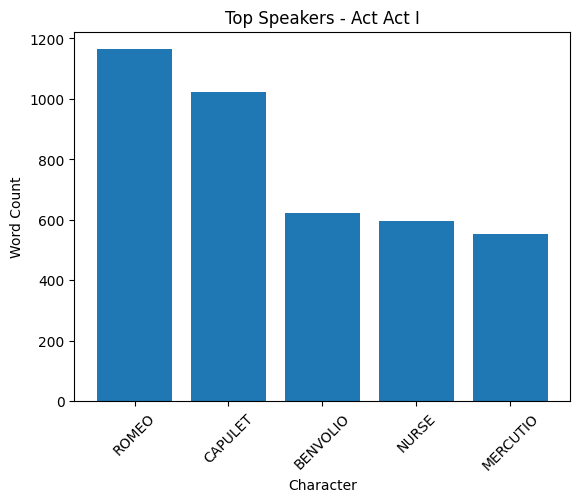

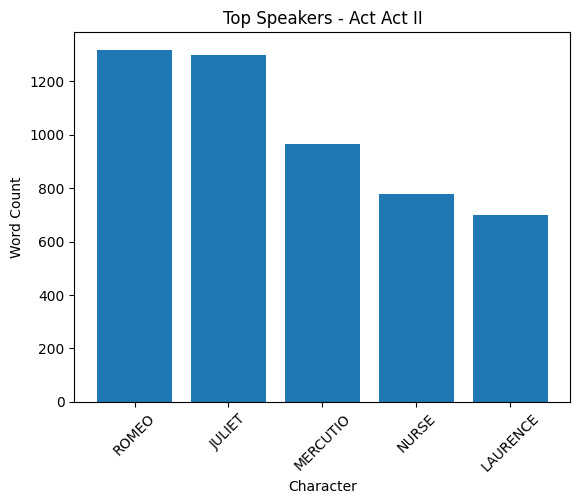

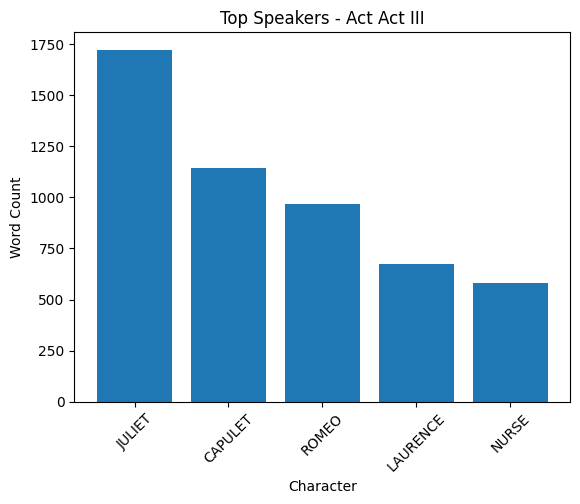

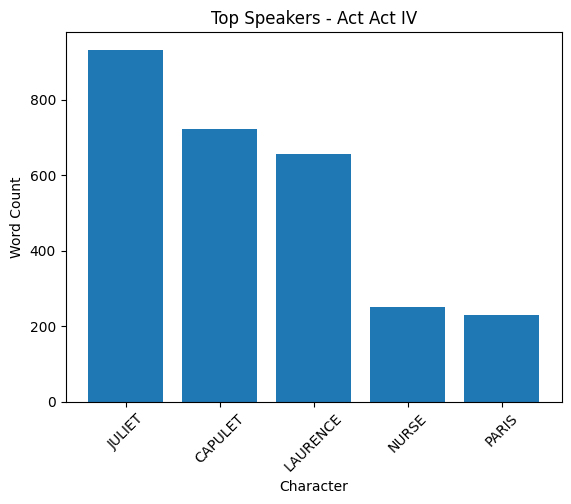

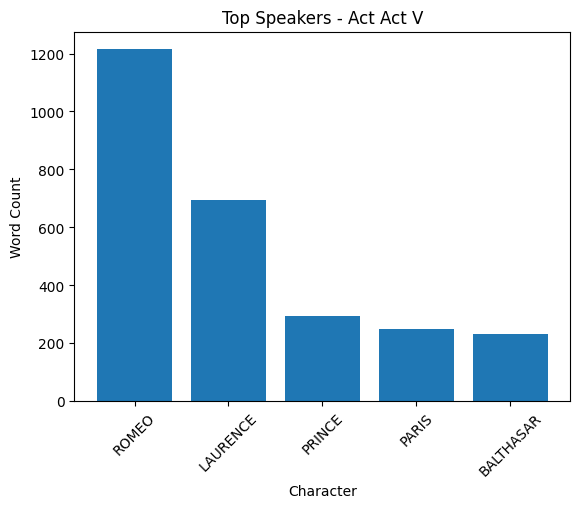

In [ ]:
# Speaker Distribution & Frequency (words per scene / act)

# --- Helper: word count ---
def count_words(text):
    if not isinstance(text, str):
        return 0
    return len(text.split())

# Create a word count column
df['word_count'] = df['dialogue'].apply(count_words)

# Remove stage directions (important!)
df_clean = df[df['character'] != '[stage direction]'].copy()

# --- Words per Scene ---
words_per_scene = (
    df_clean
    .groupby(['act', 'scene', 'normalized_name'])['word_count']
    .sum()
    .reset_index()
    .sort_values(['act', 'scene', 'word_count'], ascending=[True, True, False])
)

print("Words per Scene:")
words_per_scene.head(200)

# --- Words per Act ---
words_per_act = (
    df_clean
    .groupby(['act', 'normalized_name'])['word_count']
    .sum()
    .reset_index()
    .sort_values(['act', 'word_count'], ascending=[True, False])
)

print("Words per Act:")
words_per_act.head(200)

for act in sorted(df_clean['act'].unique()):
    subset = words_per_act[words_per_act['act'] == act].nlargest(5, 'word_count')

    plt.figure()
    plt.title(f'Top Speakers - Act {act}')
    plt.bar(subset['normalized_name'], subset['word_count'])
    plt.xticks(rotation=45)
    plt.ylabel('Word Count')
    plt.xlabel('Character')
    plt.show()

# Data visualization - Character Interaction Heatmap

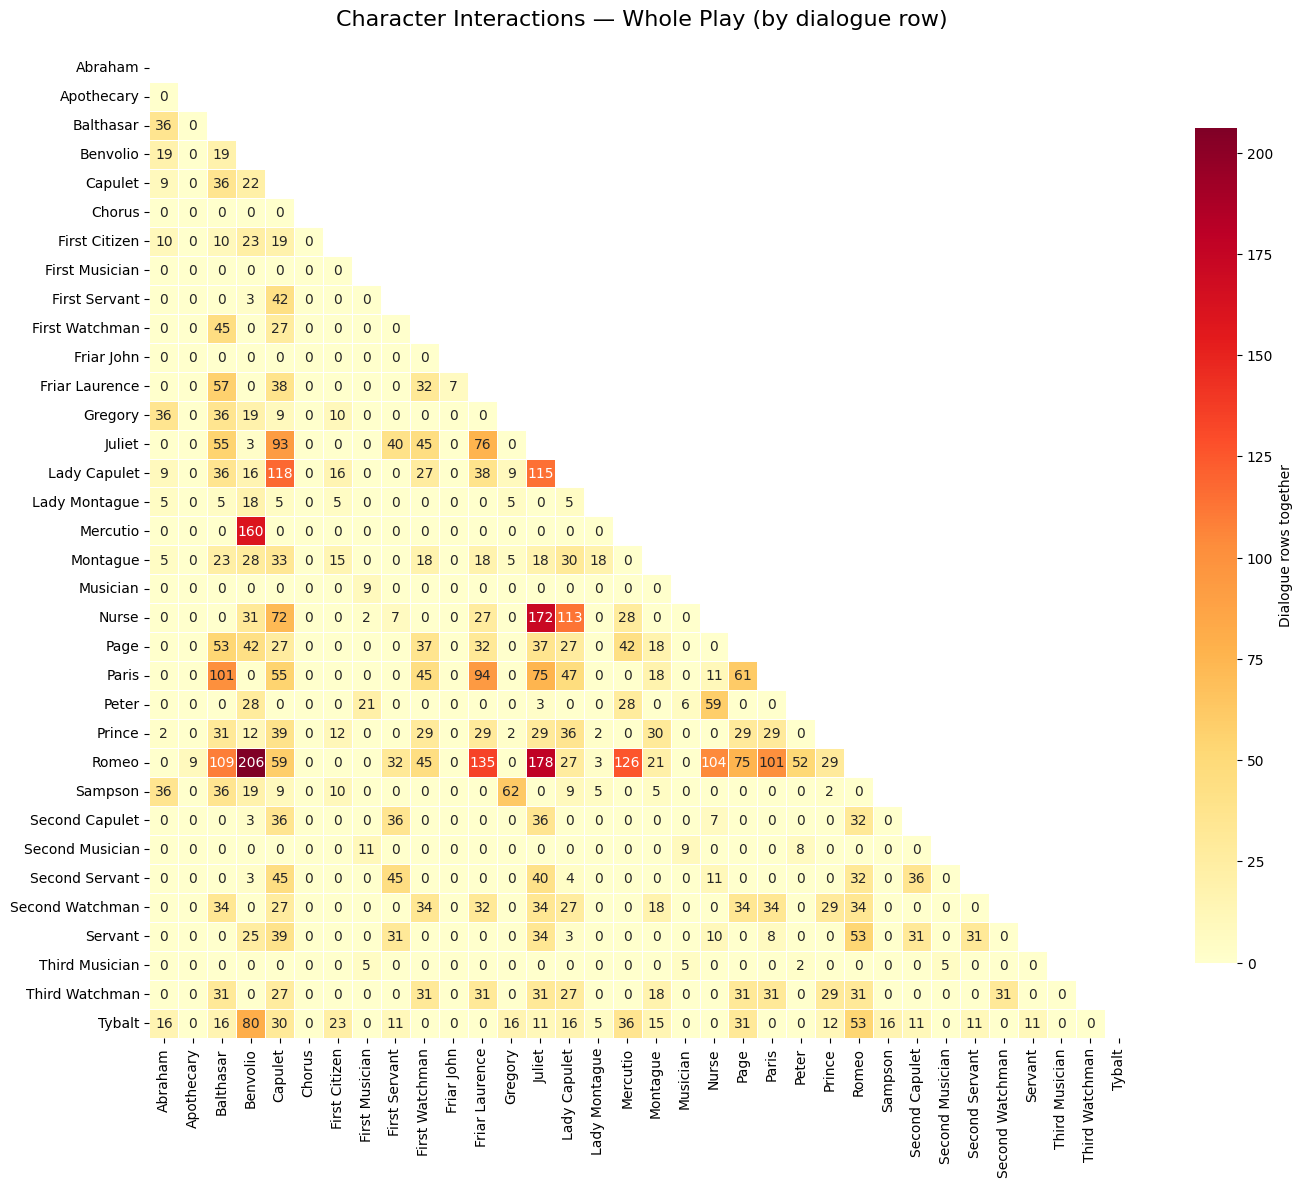

In [ ]:
# ------------------------------------------------------------------
#  1. Whole-play heatmap  (count of dialogue rows where both are present)
# ------------------------------------------------------------------
pair_counts = {}
for parts in df['participants']:
    chars = sorted(set(parts))
    for a, b in itertools.combinations(chars, 2):
        pair_counts[(a, b)] = pair_counts.get((a, b), 0) + 1

all_chars = sorted(set().union(*df['participants']))
cooc = pd.DataFrame(0, index=all_chars, columns=all_chars)
for (a, b), cnt in pair_counts.items():
    cooc.loc[a, b] = cnt
    cooc.loc[b, a] = cnt

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(cooc, dtype=bool))   # mask diagonal + upper triangle
sns.heatmap(
    cooc,
    mask=mask,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Dialogue rows together"},
)
plt.title('Character Interactions — Whole Play (by dialogue row)', fontsize=16, pad=20)
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()


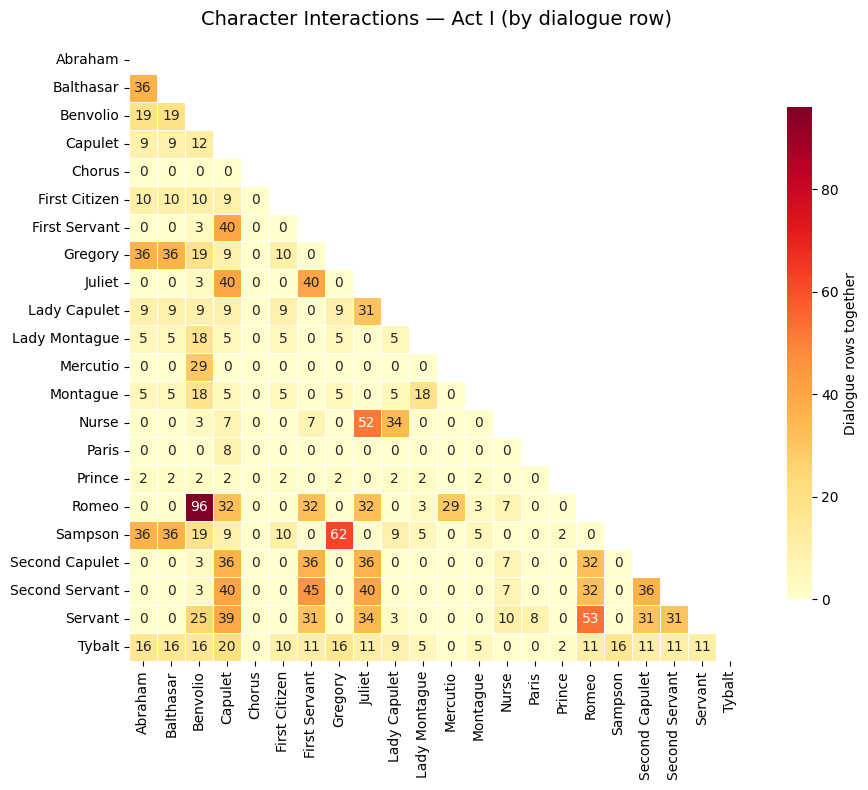

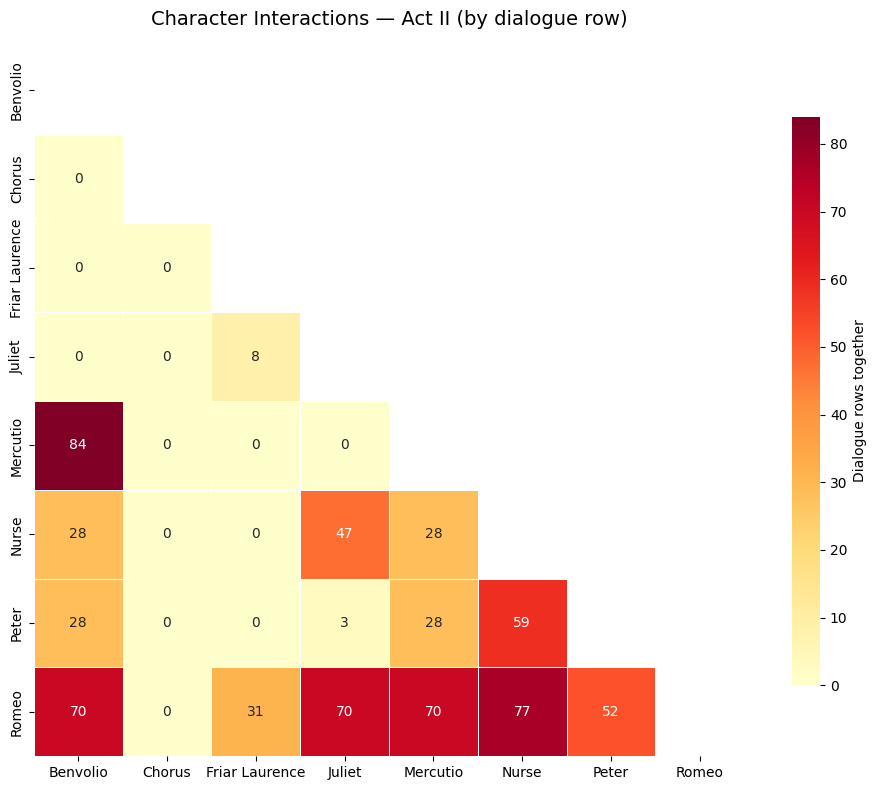

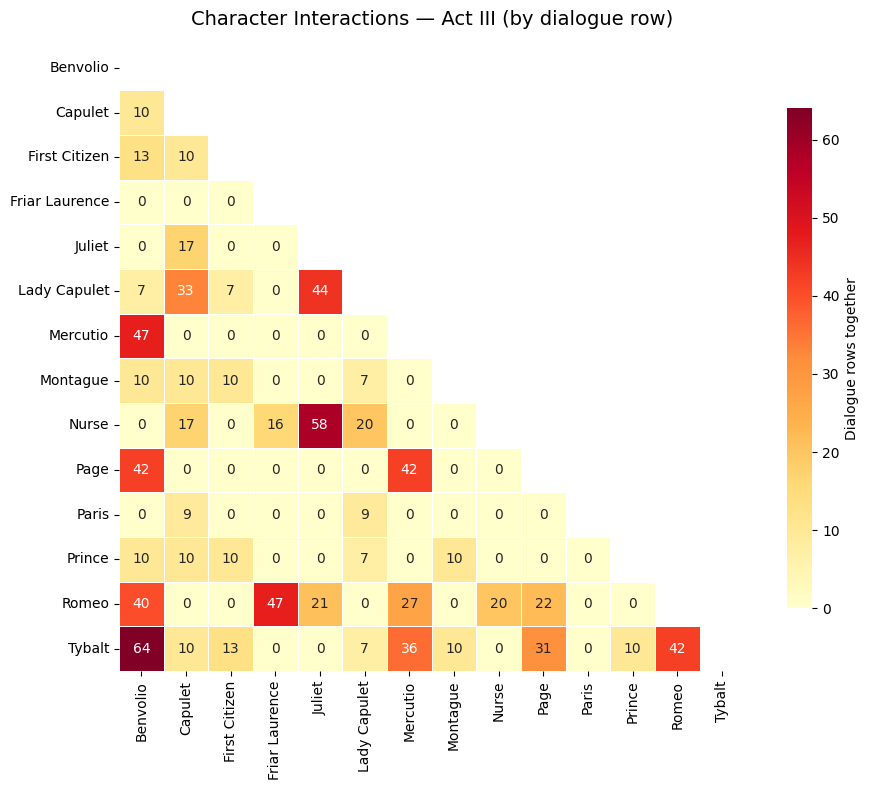

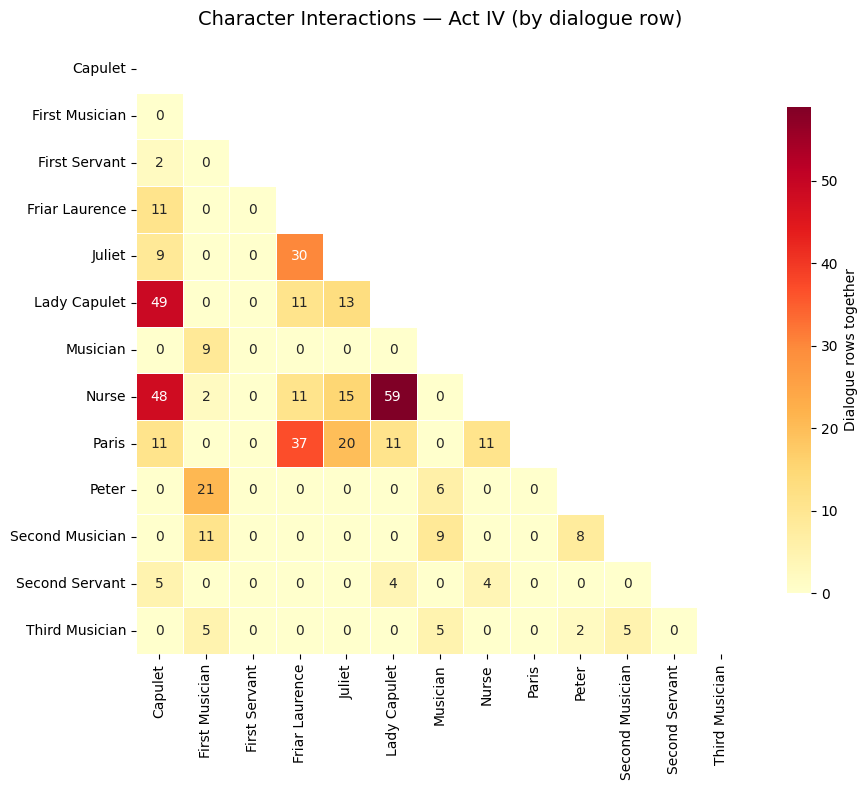

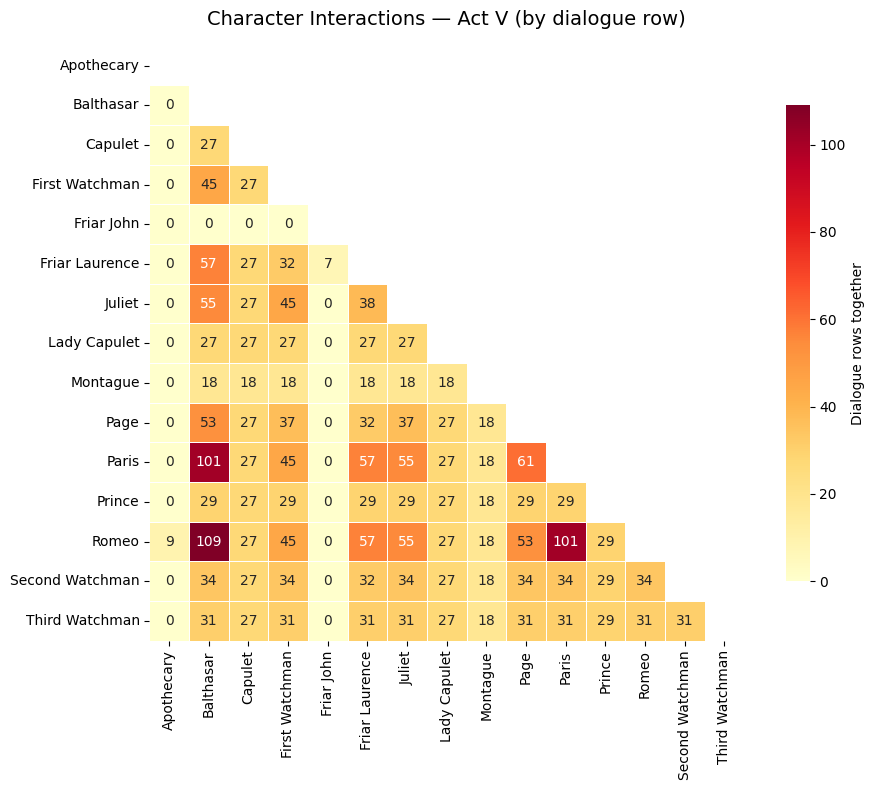

In [ ]:

# ------------------------------------------------------------------
#  2. Per-Act heatmaps
# ------------------------------------------------------------------
for act in sorted(df['act'].unique()):
    act_df = df[df['act'] == act]
    pc = {}
    for parts in act_df['participants']:
        chars = sorted(set(parts))
        for a, b in itertools.combinations(chars, 2):
            pc[(a, b)] = pc.get((a, b), 0) + 1

    if not pc:
        continue

    act_chars = sorted(set().union(*act_df['participants']))
    cooc_act = pd.DataFrame(0, index=act_chars, columns=act_chars)
    for (a, b), cnt in pc.items():
        cooc_act.loc[a, b] = cnt
        cooc_act.loc[b, a] = cnt

    plt.figure(figsize=(10, 8))
    mask = np.triu(np.ones_like(cooc_act, dtype=bool))
    sns.heatmap(
        cooc_act,
        mask=mask,
        annot=True,
        fmt='d',
        cmap='YlOrRd',
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8, "label": "Dialogue rows together"},
    )
    plt.title(f'Character Interactions — {act} (by dialogue row)', fontsize=14, pad=15)
    plt.xlabel('')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()